In [1]:
import pickle
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from FastBEMT import BEMT, Environment, Propeller, Simulation
from FastBEMT.Utils import load_propeller_dict

In [2]:
prop_name, blade_dict = load_propeller_dict('Data/10x7E')[0]

In [6]:
def run_performance_test(
    scales: list[int],
    r_observer: np.ndarray,
    check_consistency: bool = True,
) -> tuple[list[float], list[float]]:
    cpu_results: list[float] = []
    gpu_results: list[float] = []

    for size in scales:
        print(f'Testing scale: {size} time steps...')

        revolutions = max(1, size // 100)
        propeller_gpu = None
        environment = Environment(
            a_inf=343,
            rho=1.225,
            mu=1.81e-5,
            p_ref=2e-5,
        )

        # --- GPU BENCHMARK ---
        if torch.cuda.is_available():
            simulation_gpu = Simulation(
                revolutions=revolutions,
                timesteps_per_revolution=100,
                device='cuda',
            )
            propeller_gpu = Propeller(
                geometry=blade_dict,
                environment=environment,
                simulation=simulation_gpu,
                use_cuda_timing=False,
            )
            bemt_gpu = BEMT(propeller=propeller_gpu, environment=environment, rpm=7000, v_inf=0)

            # Warm-up
            propeller_gpu.run_aeroacoustics(observer_positions=r_observer, bemt=bemt_gpu)
            torch.cuda.synchronize()

            start_gpu = torch.cuda.Event(enable_timing=True)
            end_gpu = torch.cuda.Event(enable_timing=True)
            start_gpu.record()
            propeller_gpu.run_aeroacoustics(observer_positions=r_observer, bemt=bemt_gpu)
            end_gpu.record()
            torch.cuda.synchronize()
            gpu_results.append(start_gpu.elapsed_time(end_gpu))
        else:
            gpu_results.append(float('nan'))

        # --- CPU BENCHMARK ---
        simulation_cpu = Simulation(
            revolutions=revolutions,
            timesteps_per_revolution=100,
            device='cpu',
        )
        propeller_cpu = Propeller(
            geometry=blade_dict,
            environment=environment,
            simulation=simulation_cpu,
            use_cuda_timing=False,
        )
        bemt_cpu = BEMT(propeller=propeller_cpu, environment=environment, rpm=7000, v_inf=0)

        # Warm-up
        propeller_cpu.run_aeroacoustics(observer_positions=r_observer, bemt=bemt_cpu)

        start_cpu = time.perf_counter()
        propeller_cpu.run_aeroacoustics(observer_positions=r_observer, bemt=bemt_cpu)
        end_cpu = time.perf_counter()
        cpu_results.append((end_cpu - start_cpu) * 1000.0)

        if check_consistency and propeller_gpu is not None:
            propeller_cpu.postprocess()
            propeller_gpu.postprocess()

            cpu_oaspl = np.asarray(propeller_cpu.third_octave_total_oaspl)
            gpu_oaspl = np.asarray(propeller_gpu.third_octave_total_oaspl)
            abs_diff = np.abs(cpu_oaspl - gpu_oaspl)

            print(f'  Absolute difference (dB): {abs_diff}')

    return cpu_results, gpu_results

In [7]:
observer_positions = np.array([[0.0, 1.88, 0.0]])
problem_scales = [100, 500, 1000, 5000, 10000, 50000]

cpu_times, gpu_times = run_performance_test(problem_scales, observer_positions)

Testing scale: 100 time steps...


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.
[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.
[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.
  Absolute difference (dB): [7.6293945e-06]
Testing scale: 500 time steps...


...

[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.
[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.
  Absolute difference (dB): [1.5258789e-05]
Testing scale: 50000 time steps...


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.
[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.


C:\Users\Davide Pusino\Desktop\FastBEMT\src\FastBEMT\Section.py:423: UserWarning: Root finding did not converge at r = 0.127
  warnings.warn(f"Root finding did not converge at r = {self.r}")


[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.
[WARN] run_aeroacoustics dropped 1 invalid section(s) with non-finite aerodynamic/geometry data.
  Absolute difference (dB): [7.6293945e-06]


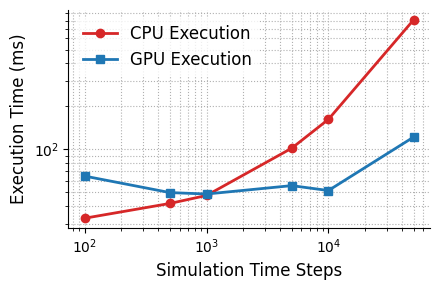

In [9]:
fig, ax = plt.subplots(figsize=(4.5, 3))
ax.plot(
    problem_scales,
    cpu_times,
    'o-',
    label='CPU Execution',
    color='tab:red',
    linewidth=2,
)
ax.plot(
    problem_scales,
    gpu_times,
    's-',
    label='GPU Execution',
    color='tab:blue',
    linewidth=2,
)

ax.set_xlabel('Simulation Time Steps', fontsize=12)
ax.set_ylabel('Execution Time (ms)', fontsize=12)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', linestyle=':', alpha=1.0)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(top=False, right=False, which='both')
ax.legend(frameon=True, edgecolor='none', fontsize=12)

plt.tight_layout()
plt.savefig('../Figures/F1A_Benchmark.pdf', dpi=200)
plt.show()